Total images: 353


100%|████████████████████████████████████████████████████████████████████████████████| 353/353 [01:25<00:00,  4.12it/s]


Feature shape: (353, 19044)
Cross Validation Accuracy: 0.8297


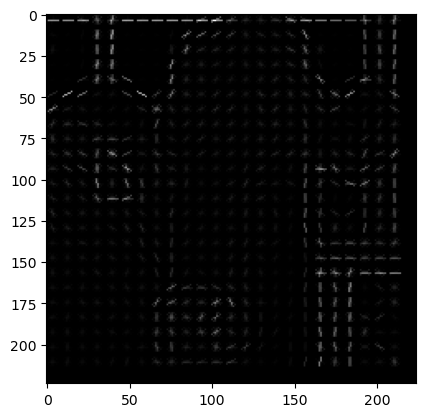

Prediction: 0
       Image Name  Prediction
0    2736 (1).JPG           0
1   2736 (10).JPG           0
2   2736 (11).JPG           4
3   2736 (12).JPG           4
4   2736 (13).JPG           0
..            ...         ...
93   2752 (5).JPG           4
94   2752 (6).JPG           4
95   2752 (7).JPG           4
96   2752 (8).JPG           4
97   2752 (9).JPG           4

[98 rows x 2 columns]


In [1]:
import cv2
import numpy as np
import pandas as pd
import os
from PIL import Image
from skimage.feature import hog
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# -------------------------------
# Step 1 : Read Training Images
# -------------------------------

folders = [
r'C:\Users\User\Desktop\NDRIKNN\IMAGESET\Training\2736',
r'C:\Users\User\Desktop\NDRIKNN\IMAGESET\Training\2738',
r'C:\Users\User\Desktop\NDRIKNN\IMAGESET\Training\2741',
r'C:\Users\User\Desktop\NDRIKNN\IMAGESET\Training\2742',
r'C:\Users\User\Desktop\NDRIKNN\IMAGESET\Training\2750',
r'C:\Users\User\Desktop\NDRIKNN\IMAGESET\Training\2752'
]

filepaths=[]
labels=[]

for label, folder in enumerate(folders):

    for dirname,_,filenames in os.walk(folder):
        for filename in filenames:
            path=os.path.join(dirname,filename)

            filepaths.append(path)
            labels.append(label)

print("Total images:",len(filepaths))

# -------------------------------
# Step 2 : HOG Feature Extraction
# -------------------------------

data=[]
image_arr=[]

for path in tqdm(filepaths):

    img=Image.open(path)
    img=img.resize((224,224))

    a=np.asarray(img)

    gray=cv2.cvtColor(a,cv2.COLOR_RGB2GRAY)

    fd,hog_img=hog(gray,
                   orientations=9,
                   pixels_per_cell=(9,9),
                   cells_per_block=(2,2),
                   visualize=True)

    data.append(fd)
    image_arr.append(a)

print("Feature shape:",np.shape(data))

# -------------------------------
# Step 3 : Create DataFrame
# -------------------------------

df=pd.DataFrame()
df["filepath"]=filepaths
df["label"]=labels
df["Imagearr"]=image_arr
df["hog"]=data

# -------------------------------
# Step 4 : Train KNN Model
# -------------------------------

knn_model = KNeighborsClassifier(n_neighbors=1)

kfold = KFold(n_splits=14, shuffle=True, random_state=123)

scores = cross_val_score(knn_model, data, labels, cv=kfold)

model = knn_model.fit(data, labels)

print("Cross Validation Accuracy: %0.4f" % scores.mean())

# -------------------------------
# Step 5 : Test Single Image
# -------------------------------

img_original = cv2.imread(r'C:\Users\User\Desktop\NDRIKNN\IMAGESET\Testing\2736 (1).JPG')

img = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)

img = cv2.resize(img, (224,224))

fd4, hog_img_gray = hog(img,
                        orientations=9,
                        pixels_per_cell=(9,9),
                        cells_per_block=(2,2),
                        visualize=True)

plt.imshow(hog_img_gray, cmap="gray")
plt.show()

pred = int(model.predict(fd4.reshape(1,-1))[0])

print("Prediction:", pred)

# -------------------------------
# Step 6 : Predict Testing Folder
# -------------------------------

F=[]
P=[]

folder=r"C:\Users\User\Desktop\NDRIKNN\IMAGESET\Testing"

for filename in os.listdir(folder):

    img_original = cv2.imread(os.path.join(folder,filename))

    img = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)

    img = cv2.resize(img,(224,224))

    fd4,hog_img = hog(img,
                      orientations=9,
                      pixels_per_cell=(9,9),
                      cells_per_block=(2,2),
                      visualize=True)

    predict = model.predict(fd4.reshape(1,-1))[0]

    F.append(filename)
    P.append(predict)

# -------------------------------
# Step 7 : Save Result
# -------------------------------

result = pd.DataFrame()

result["Image Name"] = F
result["Prediction"] = P

result.to_excel(r"C:\Users\User\Desktop\NDRIKNN\RESULT\KNN.xlsx", index=False)

print(result)